### Import Packages

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

### Import Data 

In [2]:
df = pd.read_csv('/Users/baselhussein/Projects/impossible_goals/data/cluster_features.csv')
df

,ID,unique_goals,total_returns,seconds_per_goal,seconds_to_first_goal_switch,impasses,input_count_exploring,time_in_level_seconds
0,2,2,0,18.233000,13.416,7,110,82.466
1,6,2,0,4.408000,8.816,0,15,13.050
2,12,7,9,12.821286,17.533,17,230,148.016
3,13,6,2,18.163833,9.300,52,365,281.800
4,22,2,0,7.533500,15.067,9,31,24.300
...,...,...,...,...,...,...,...,...
145,252,7,7,53.342714,14.133,48,371,513.935
146,253,7,23,41.769000,10.450,91,751,562.183
147,255,6,10,34.372000,8.283,65,298,305.316
148,257,5,11,102.930000,25.350,41,124,586.083


### Explore Data 

In [3]:
# Explore basic statistics
print(df.describe())

               ID  unique_goals  total_returns  seconds_per_goal  \
count  150.000000    150.000000     150.000000        150.000000   
mean   146.613333      4.206667       4.146667         29.163078   
std     73.813004      1.643767       5.732735         28.895094   
min      2.000000      2.000000       0.000000          2.425000   
25%     81.500000      3.000000       1.000000          8.997250   
50%    157.000000      4.000000       2.000000         17.454583   
75%    210.750000      5.000000       5.000000         39.416083   
max    258.000000      9.000000      33.000000        151.695500   

       seconds_to_first_goal_switch    impasses  input_count_exploring  \
count                    150.000000  150.000000             150.000000   
mean                      14.132740   27.893333             156.966667   
std                        9.009222   35.317951             185.058758   
min                        0.383000    0.000000               8.000000   
25%              

In [4]:
df_numeric = df.drop(columns=['ID'])

In [5]:
correlation_matrix = df_numeric.corr()
correlation_matrix

,unique_goals,total_returns,seconds_per_goal,seconds_to_first_goal_switch,impasses,input_count_exploring,time_in_level_seconds
unique_goals,1.000000,0.728920,0.396214,-0.029212,0.629507,0.740655,0.698937
total_returns,0.728920,1.000000,0.550054,-0.048029,0.756480,0.818816,0.789779
seconds_per_goal,0.396214,0.550054,1.000000,0.264339,0.699949,0.511706,0.851531
seconds_to_first_goal_switch,-0.029212,-0.048029,0.264339,1.000000,0.044713,-0.056809,0.104407
impasses,0.629507,0.756480,0.699949,0.044713,1.000000,0.762706,0.865757
input_count_exploring,0.740655,0.818816,0.511706,-0.056809,0.762706,1.000000,0.837384
time_in_level_seconds,0.698937,0.789779,0.851531,0.104407,0.865757,0.837384,1.000000


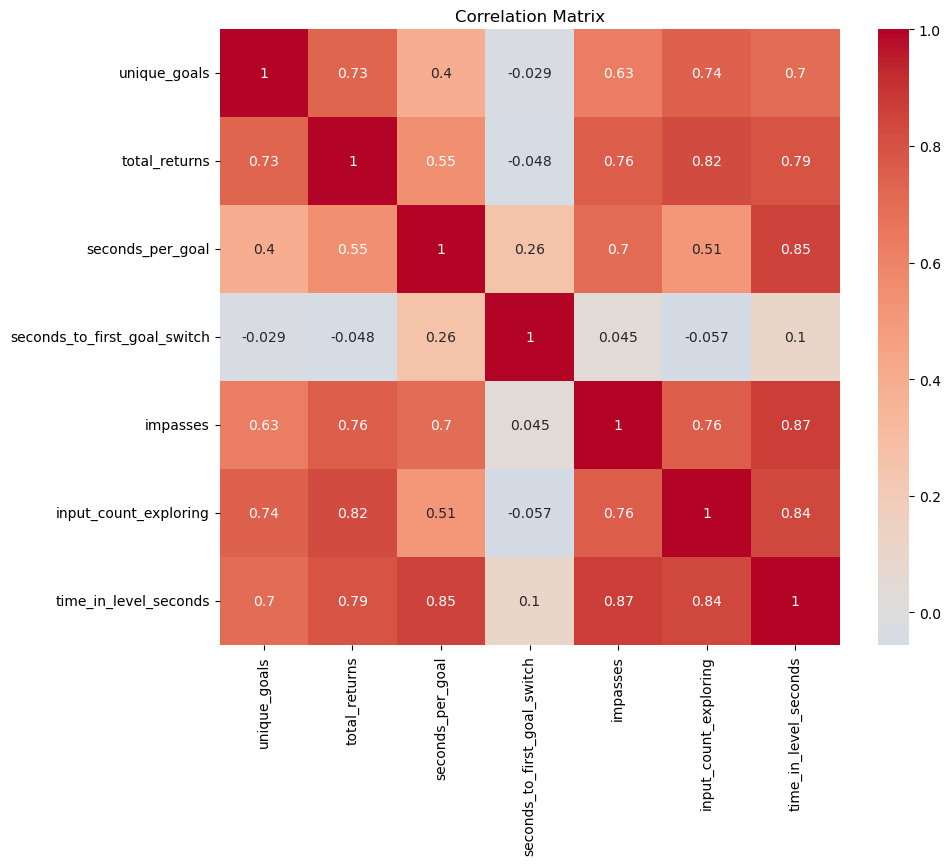

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

### Preprocessing

#### Scale Manually 

In [7]:
scaled_data = df_numeric.to_numpy()
scaled_data

array([[2.00000000e+00, 0.00000000e+00, 1.82330000e+01, 1.34160000e+01,
        7.00000000e+00, 1.10000000e+02],
       [2.00000000e+00, 0.00000000e+00, 4.40800000e+00, 8.81600000e+00,
        0.00000000e+00, 1.50000000e+01],
       [7.00000000e+00, 9.00000000e+00, 1.28212857e+01, 1.75330000e+01,
        1.70000000e+01, 2.30000000e+02],
       [6.00000000e+00, 2.00000000e+00, 1.81638333e+01, 9.30000000e+00,
        5.20000000e+01, 3.65000000e+02],
       [2.00000000e+00, 0.00000000e+00, 7.53350000e+00, 1.50670000e+01,
        9.00000000e+00, 3.10000000e+01],
       [3.00000000e+00, 1.00000000e+00, 9.36560000e+01, 3.15000000e+01,
        1.40000000e+01, 1.11000000e+02],
       [3.00000000e+00, 1.00000000e+00, 6.60000000e+00, 3.83000000e-01,
        8.00000000e+00, 2.80000000e+01],
       [5.00000000e+00, 3.00000000e+00, 3.38036000e+01, 1.65170000e+01,
        1.40000000e+01, 1.46000000e+02],
       [3.00000000e+00, 0.00000000e+00, 7.07766667e+00, 1.83500000e+01,
        1.40000000e+01, 

#### Scale scikit

In [8]:
# # Scale numeric features
# scaler = StandardScaler()
# scaled_data = scaler.fit_transform(df_numeric)
# scaled_data

### Explore K Values

/Users/baselhussein/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/baselhussein/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/baselhussein/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/baselhussein/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of

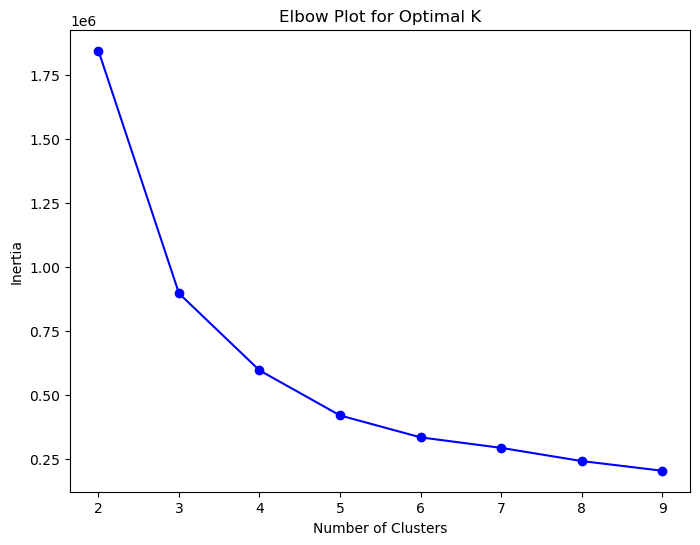

In [9]:
# Define the range of cluster numbers to try
cluster_range = range(2, 10)
inertia = []

# Calculate inertia (within-cluster sum of squared distances) for each cluster number
for num_clusters in cluster_range:
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# Plot the elbow plot
plt.figure(figsize=(8, 6))
plt.plot(cluster_range, inertia, marker='o', linestyle='-', color='b')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Plot for Optimal K')
plt.xticks(cluster_range)
plt.show()

### Define Clusters 

In [24]:
# Initialize KMeans
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit KMeans to the scaled data
kmeans.fit(scaled_data)

# Assign clusters to the data
df_numeric['Cluster'] = kmeans.labels_

/Users/baselhussein/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [25]:
kmeans.labels_

array([1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 2, 1, 1, 1, 1, 2, 1, 1,
       2, 1, 1, 1, 1, 2, 0, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1,
       1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 2, 2, 1,
       1, 1, 1, 1, 2, 1, 0, 1, 1, 1, 0, 2, 1, 0, 2, 2, 1, 1, 1, 1, 2, 2,
       1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 2,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 2, 1,
       1, 1, 1, 1, 2, 1, 1, 1, 2, 0, 2, 1, 1, 2, 0, 2, 1, 0], dtype=int32)

In [20]:
# Calculate silhouette score

silhouette_avg = silhouette_score(scaled_data, kmeans.labels_)
print("Silhouette Score:", silhouette_avg)

Silhouette Score: 0.5955427406262296


In [12]:
df_numeric

,unique_goals,total_returns,seconds_per_goal,seconds_to_first_goal_switch,impasses,input_count_exploring,Cluster
0,2,0,18.233000,13.416,7,110,0
1,2,0,4.408000,8.816,0,15,3
2,7,9,12.821286,17.533,17,230,4
3,6,2,18.163833,9.300,52,365,2
4,2,0,7.533500,15.067,9,31,3
...,...,...,...,...,...,...,...
145,7,7,53.342714,14.133,48,371,2
146,7,23,41.769000,10.450,91,751,1
147,6,10,34.372000,8.283,65,298,4
148,5,11,102.930000,25.350,41,124,0


### Visualization

In [13]:
### TODO

### Spot-Check

In [14]:
df_numeric.to_csv('/Users/baselhussein/Downloads/df_numeric_check.csv', index=False)